# **TRABAJO PRÁCTICO N° 2 - Mineria de Datos**

# Predicción de lluvia en Australia 
---
##### 1er Cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
|Bartomioli Ornella         |(Dni) 47077671 |
| Stefano Candela           | S-5872/6   |
| Vera Nahir Sol            | V-3139/9   |


##### **Docentes:** 


Librerias:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, mean_absolute_error,
                             mean_squared_error,classification_report,ConfusionMatrixDisplay,roc_curve, auc)
from sklearn.preprocessing import StandardScaler


# 1) Carga y análisis de los datos.

In [2]:
# Carga y visuaización del conjunto de Datos
lluvias = pd.read_csv('weatherAUS_2026C1.csv')
lluvias.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [3]:
lluvias = lluvias.rename(columns={
    'Unnamed: 0': 'id',
    'Date': 'fecha',
    'Location': 'ubicacion',
    'MinTemp': 'temp_min',
    'MaxTemp': 'temp_max',
    'Rainfall': 'lluvia',
    'Evaporation': 'evaporacion',
    'Sunshine': 'horas_sol',
    'WindGustDir': 'dir_rafaga_viento',
    'WindGustSpeed': 'vel_rafaga_viento',
    'WindDir9am': 'dir_viento_9am',
    'WindDir3pm': 'dir_viento_3pm',
    'WindSpeed9am': 'vel_viento_9am',
    'WindSpeed3pm': 'vel_viento_3pm',
    'Humidity9am': 'humedad_9am',
    'Humidity3pm': 'humedad_3pm',
    'Pressure9am': 'presion_9am',
    'Pressure3pm': 'presion_3pm',
    'Cloud9am': 'nubes_9am',
    'Cloud3pm': 'nubes_3pm',
    'Temp9am': 'temp_9am',
    'Temp3pm': 'temp_3pm',
    'RainToday': 'llovio_hoy',
    'RainTomorrow': 'llueve_manana',
    'RainfallTomorrow': 'lluvia_manana'})

lluvias.head()

,id,fecha,ubicacion,temp_min,temp_max,lluvia,evaporacion,horas_sol,dir_rafaga_viento,vel_rafaga_viento,...,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,llovio_hoy,llueve_manana,lluvia_manana
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [4]:
# Trataamiendo variable 'Date'
lluvias['fecha'] = pd.to_datetime(lluvias['fecha'])
lluvias['mes'] = lluvias['fecha'].dt.month

lluvias = lluvias.drop(columns=['fecha'])

Se transformó la variable fecha a datetime para poder trabajar adecuadamente con ella y extraer la información correspondiente al mes de cada observación.

In [5]:
# Eliminación Variable 'id'
lluvias = lluvias.drop(columns=['id'])

Se eliminó la variable id, ya que actúa únicamente como un identificador y no aporta información para el análisis.

In [6]:
lluvias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ubicacion          145412 non-null  object 
 1   temp_min           143928 non-null  float64
 2   temp_max           144159 non-null  float64
 3   lluvia             142152 non-null  float64
 4   evaporacion        82658 non-null   float64
 5   horas_sol          75616 non-null   float64
 6   dir_rafaga_viento  135096 non-null  object 
 7   vel_rafaga_viento  135159 non-null  float64
 8   dir_viento_9am     134850 non-null  object 
 9   dir_viento_3pm     141186 non-null  object 
 10  vel_viento_9am     143645 non-null  float64
 11  vel_viento_3pm     142351 non-null  float64
 12  humedad_9am        142759 non-null  float64
 13  humedad_3pm        140907 non-null  float64
 14  presion_9am        130351 non-null  float64
 15  presion_3pm        130388 non-null  float64
 16  nu

 **Análisis de Variables:**

In [7]:
lluvias.describe()

,temp_min,temp_max,lluvia,evaporacion,horas_sol,vel_rafaga_viento,vel_viento_9am,vel_viento_3pm,humedad_9am,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,lluvia_manana,mes
count,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000,145412.000000
mean,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242,6.399747
std,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084,3.427820
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,6.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000,12.000000


In [8]:
# Verificación de las localidades
ubicaciones = lluvias['ubicacion'].unique()
print(ubicaciones)

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


Analizamos las ubicaciones registradas con el objetivo de verificar su correcta codificación y asegurar la ausencia de valores duplicados o inconsistencias en su representación.

In [9]:
# Valores posibles para llovio_hoy :
lluvias['llovio_hoy'].unique()

array(['No', 'Yes', nan], dtype=object)

In [10]:
# Valores posibles para llueve_manana :
lluvias['llueve_manana'].unique()

array(['No', 'Yes', nan], dtype=object)

**Variables temporales:**
Numérica discreta.
* mes: mes de la observación. Valores del 1 al 12.

**Varibale de Ubicación:**
Categórica.
* ubicacion: ciudad de Australia. 

**Variables de temperatura:**
Numéricas continuas.
* temp_min : temperatura mínima en el día. (-9.7 a 34)
* temp_max: temperatura máxima en el día. (-5 a 49)
* temp_9am: temperatura a las 9am.(-8 a 39)
* temp_3pm: temperatura a las 3pm.(-5.8 a 47)

**Variables de viento:**
Categóricas.
* dir_rafaga_viento: dirección de la ráfaga de viento. 
* dir_viento_9am y dir_viento_3pm: dirección del viento a las 9am. y 3pm. ()
* vel_viento_9am y vel_viento_3pm: velocidad del viento a las 9am. y 3pm.()

Numérica continua.
* vel_rafaga_viento: velocidad de la ráfaga de viento. (0 a 130)

**Variables de humedad y presión:**
Numéricas continuas.
* humedad_9am y humedad_3pm: porcentaje de humedad a las 9am. y 3pm. (0 a 100)
* presion_9am y presion_3pm: presión atmosférica medida en hPa a las 9am. y 3pm. (980.300000 a 1041.200000) y (977.400000 a 1039.800000)

**Variables del clima:**
* nubes_9am y nubes_3pm: nivel de nubosidad.
* horas_sol: horas de sol. (7 a 14)
* evaporacion: nivel de evaporación. (0 a 145)

**Variables de hecho:**
* llovio_hoy: 
* llueve_manana: llovió al día siguiente o no.
* lloveria_manana


**Valores Faltantes:**

In [11]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (lluvias.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos

,Cantidad_nulos,Porcentaje_nulos
horas_sol,69796,47.998790
evaporacion,62754,43.155998
nubes_3pm,59336,40.805436
nubes_9am,55870,38.421863
presion_9am,15061,10.357467
presion_3pm,15024,10.332022
dir_viento_9am,10562,7.263500
dir_rafaga_viento,10316,7.094325
vel_rafaga_viento,10253,7.051000
humedad_3pm,4505,3.098094


Se observa una gran cantidad de valores faltantes, luego de hacer la división train/test los trabajaremos.

In [12]:
# Eliminacion de las observaciones con la variable objetivo Nan:
lluvias = lluvias[lluvias['llueve_manana'].notna()]

Eliminamos los registros que no contaban con la variable a predecir.

In [13]:
# Lista de columnas donde decidimos eliminar las filas con nulos
col_nan = ['dir_viento_9am', 'dir_rafaga_viento', 'vel_rafaga_viento', 'humedad_3pm', 'dir_viento_3pm', 'temp_3pm', 'llovio_hoy', 
    'lluvia', 'llueve_manana', 'lluvia_manana', 'vel_viento_3pm', 'humedad_9am', 'vel_viento_9am', 'temp_9am', 'temp_min', 'temp_max']

lluvias = lluvias.dropna(subset=col_nan).copy()
print(f"Registros después de la limpieza: {lluvias.shape[0]}")

Registros después de la limpieza: 121757


Eliminamos los registros co valores faltantes en las variables que presentaban menos proporcion de nan.

In [14]:
lluvias['llueve_manana'].value_counts(normalize=True) * 100

llueve_manana
No     77.923241
Yes    22.076759
Name: proportion, dtype: float64

El dataset no se encuentra balanceado, ya que predominan los registros correspondientes a días en los que no llueve. El desbalance de clases puede afectar el rendimiento del modelo de clasificación, provocando que tienda a predecir con mayor frecuencia la clase mayoritaria. Métricas como accuracy pueden resultar engañosas, por lo que es importante analizar también precisión, recall y matriz de confusión.

# 2) División Conjuntos Train y Test:

In [34]:
# Separamos X e y:
X = lluvias.drop('llueve_manana', axis=1)
y = lluvias['llueve_manana']

In [35]:
# Dividir train y test:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# 3) Limpieza y tratamiento:

### Tratamiento de Valores Faltantes:

In [36]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (X_train.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos.head(7)

,Cantidad_nulos,Porcentaje_nulos
horas_sol,55045,36.149872
evaporacion,49877,32.786616
nubes_3pm,46727,30.724312
nubes_9am,45385,29.862759
presion_9am,8826,5.833751
presion_3pm,8775,5.796792
dir_rafaga_viento,0,0.000000


Se decidió imputar los valores faltantes de las variables horas_sol, evaporación, nubes_3pm, nubes_9am, presion_9am y presion_3pm, ya que todas presentan mayor proporción de observaciones nulas. Utilizamos la media, considerando la ubicación y el mes como criterios de agrupación, con el objetivo representar la estacion y la geográfica de los datos.

In [18]:
def imputar_por_ubi_y_mes(datos, columna):
    """
    Imputa valores nulos de una columna usando la media agrupada por ubicacion y mes.
    """

    datos[columna] =datos[columna].fillna( datos.groupby(['ubicacion', 'mes'])[columna].transform('mean'))

    # Caso de no tener registros para esa configuracion
    datos[columna] = datos[columna].fillna(datos[columna].mean())

    return datos


In [37]:
# Imputación X_train:
col_imputar = ['horas_sol','evaporacion','nubes_3pm','nubes_9am','presion_9am','presion_3pm']

for col in col_imputar:
    X_train = imputar_por_ubi_y_mes(X_train, col)

In [38]:
# Imputación X_test con los valores de X_train
for col in col_imputar:

    # medias del train
    medias_grupo = X_train.groupby(['ubicacion', 'mes'])[col].mean()
    media_global = X_train[col].mean()

    # PASO A: imputación por grupo
    X_test[col] = X_test.apply(
        lambda row: medias_grupo.get((row['ubicacion'], row['mes']), None)
        if pd.isnull(row[col]) else row[col],
        axis=1)

    # PASO B: imputación global
    X_test[col] = X_test[col].fillna(media_global)


Para el resto de las variables, que presentaban menos del 10% de registros faltantes, se optó por eliminar las observaciones correspondientes.

### Análisis de distribuciones:

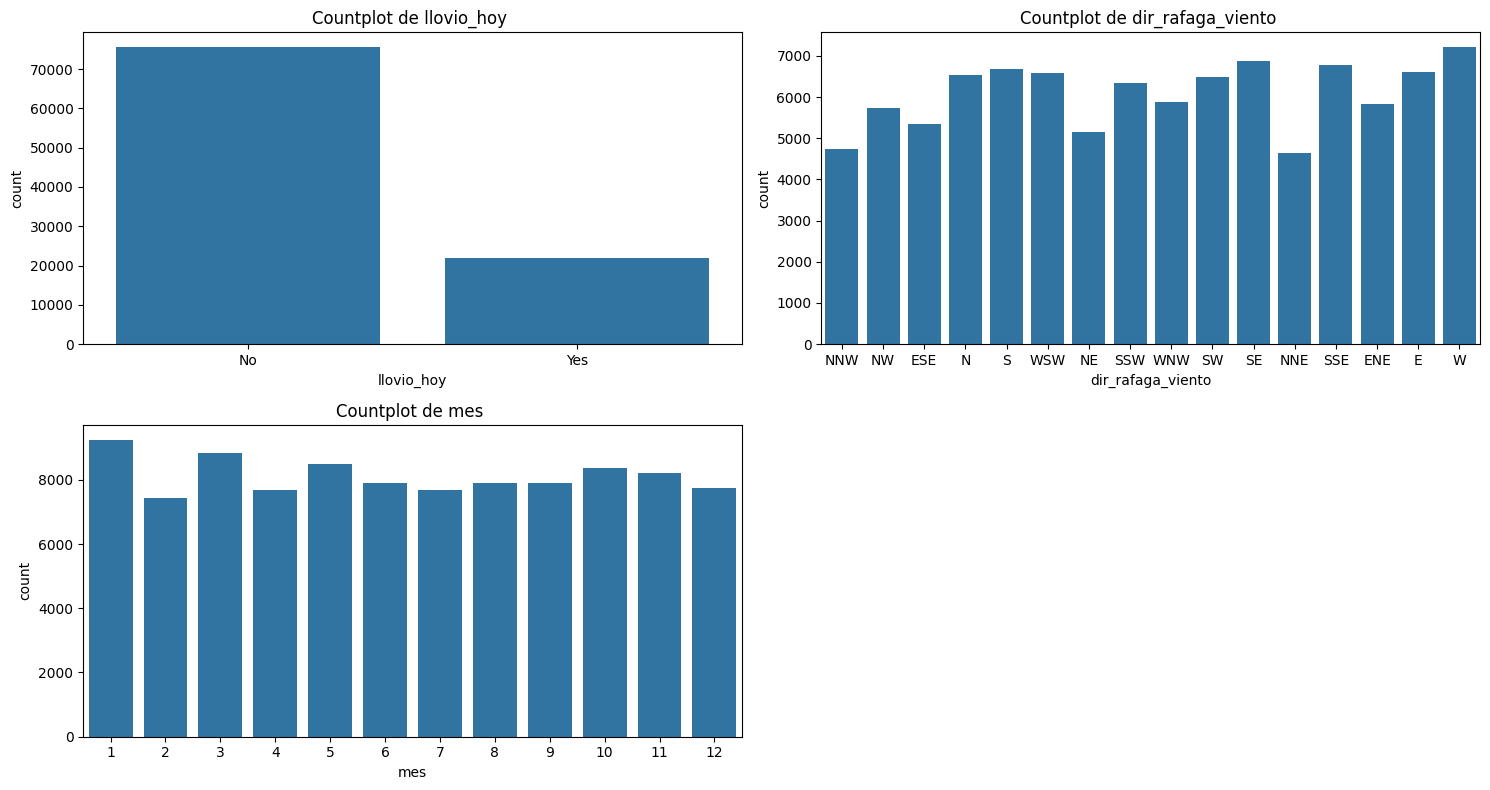

In [21]:
# COUNTPLO:
cols_cat = ['llovio_hoy','dir_rafaga_viento','mes']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=X_train, x=col)
    plt.title(f"Countplot de {col} ")

plt.tight_layout()
plt.show()

#VER COMO PONEMOS LAS UBIVACIONES,PERO LAS PRIMAS 10

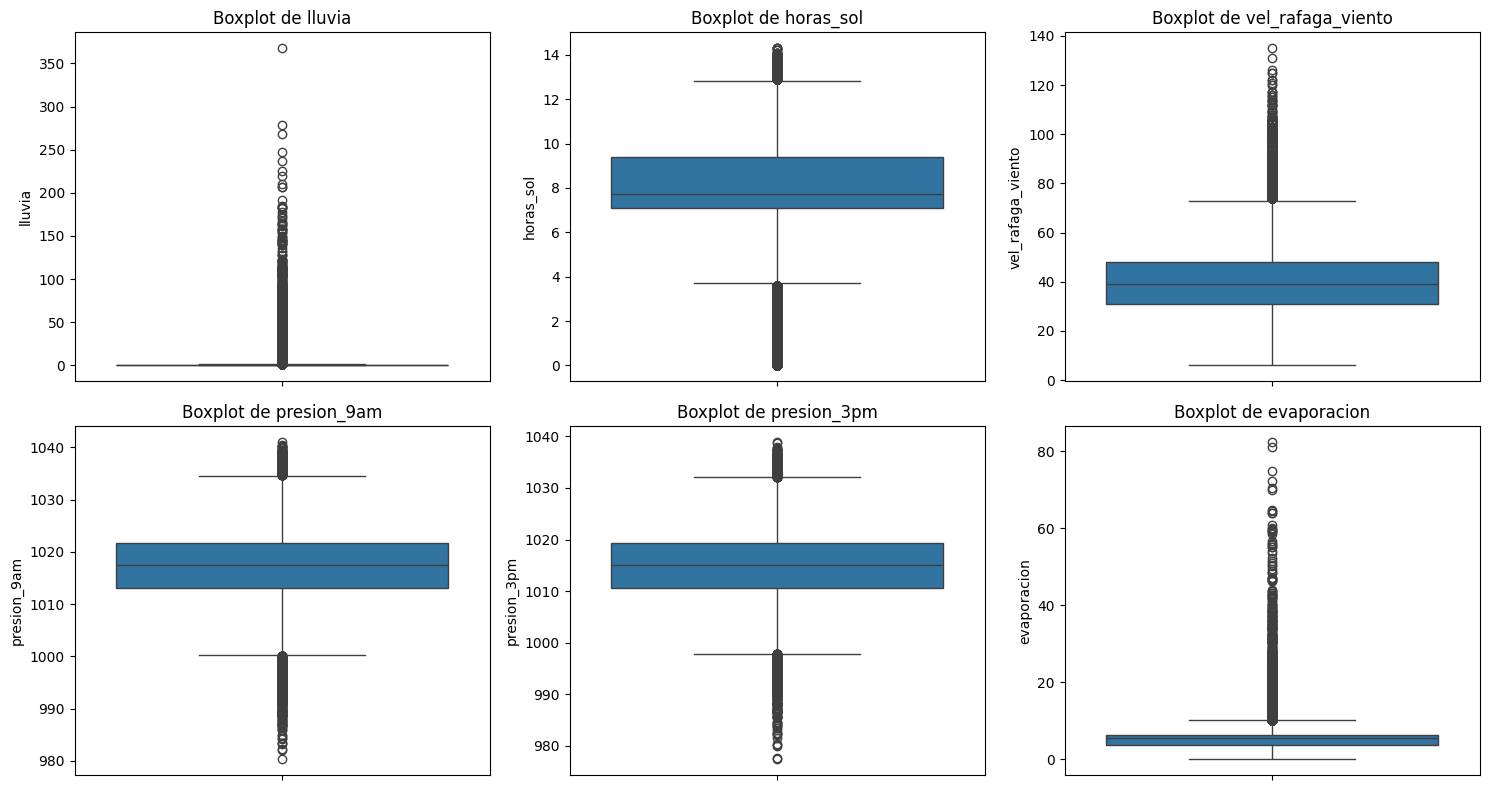

In [22]:
# BOXPLOTS
cols_num = ['lluvia','horas_sol', 'vel_rafaga_viento', 'presion_9am','presion_3pm','evaporacion']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

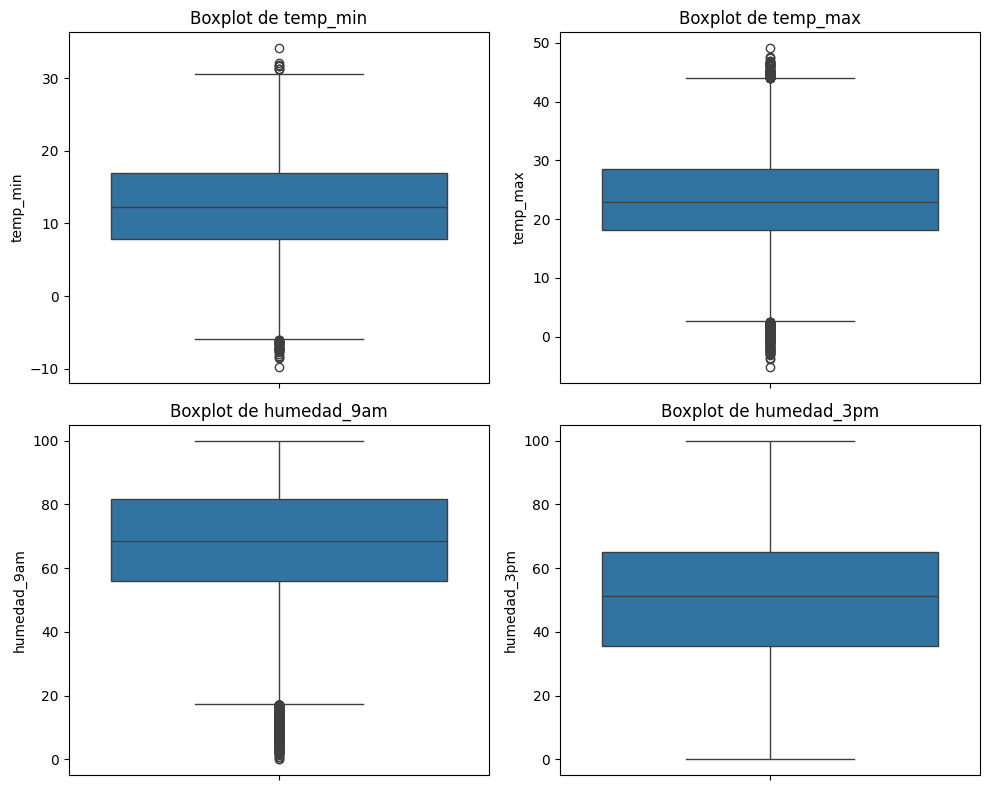

In [23]:
cols_num = ['temp_min', 'temp_max','humedad_9am', 'humedad_3pm']

plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

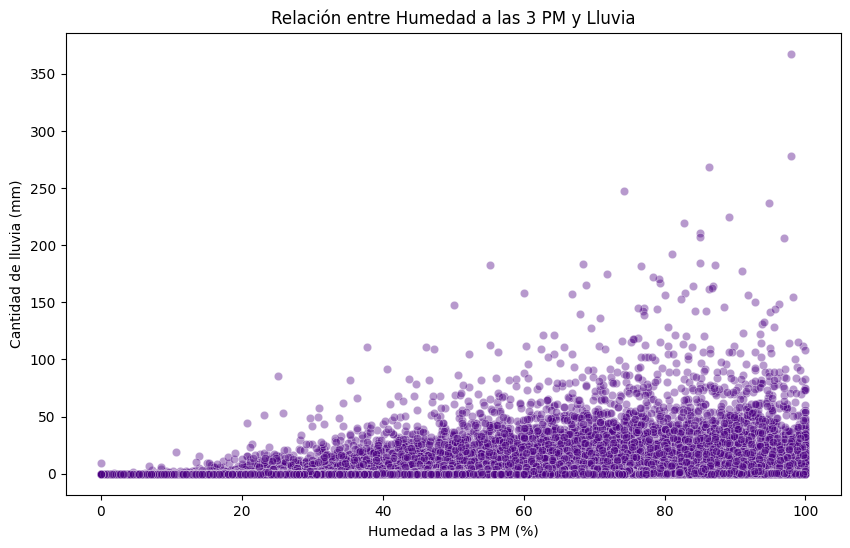

In [24]:
# SCATTERPLOT (humedad_3pm vs lluvia)

plt.figure(figsize=(10,6))
sns.scatterplot( data=X_train, x='humedad_3pm', y='lluvia', alpha=0.4, color='indigo')
plt.title('Relación entre Humedad a las 3 PM y Lluvia')
plt.xlabel('Humedad a las 3 PM (%)')
plt.ylabel('Cantidad de lluvia (mm)')
plt.show()

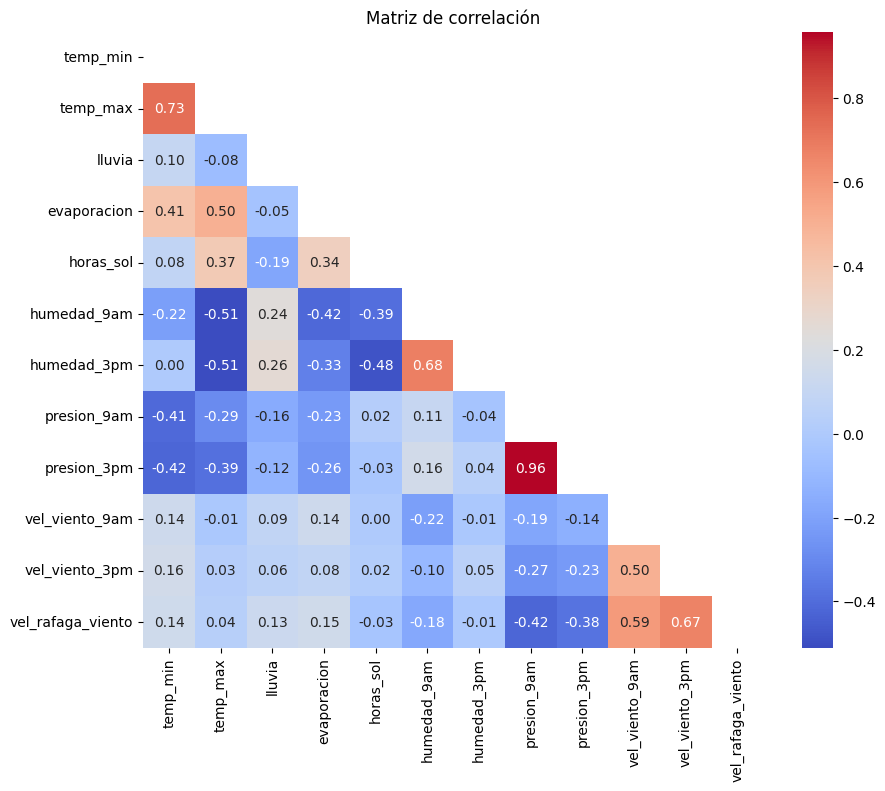

In [39]:
#MATRIZ DE CORRELACIÓN:
vars_corr = ['temp_min','temp_max','lluvia','evaporacion','horas_sol','humedad_9am','humedad_3pm',
             'presion_9am','presion_3pm','vel_viento_9am','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

Se detecto una posible de multicolinealidad, destacándose la relación entre presion_9am y presion_3pm con un coeficiente de 0.96. Para evitar redundancias que afecten la estabilidad de los coeficientes de la Regresión Logística, se decidió eliminar la variable presion_9am. Asimismo, se mantuvo un seguimiento sobre las variables de temperatura y viento, priorizando aquellas con mayor capacidad descriptiva según el análisis visual.

In [40]:
cols_a_eliminar = ['presion_9am', 'temp_min', 'humedad_9am', 'vel_viento_9am']

X_train = X_train.drop(columns=cols_a_eliminar)
X_test = X_test.drop(columns=cols_a_eliminar)

print(f"Nuevas dimensiones - Train: {X_train.shape}, Test: {X_test.shape}")

Nuevas dimensiones - Train: (97405, 19), Test: (24352, 19)


### Codificación de variables categóricas:

In [41]:
# Lueve_hoy:
X_train['llovio_hoy'] = X_train['llovio_hoy'].map({'No':0, 'Yes':1})
X_test['llovio_hoy'] = X_test['llovio_hoy'].map({'No':0, 'Yes':1})

In [42]:
# Lueve_manana:
y_train = y_train.map({'No':0, 'Yes':1})
y_test =  y_test.map({'No':0, 'Yes':1})

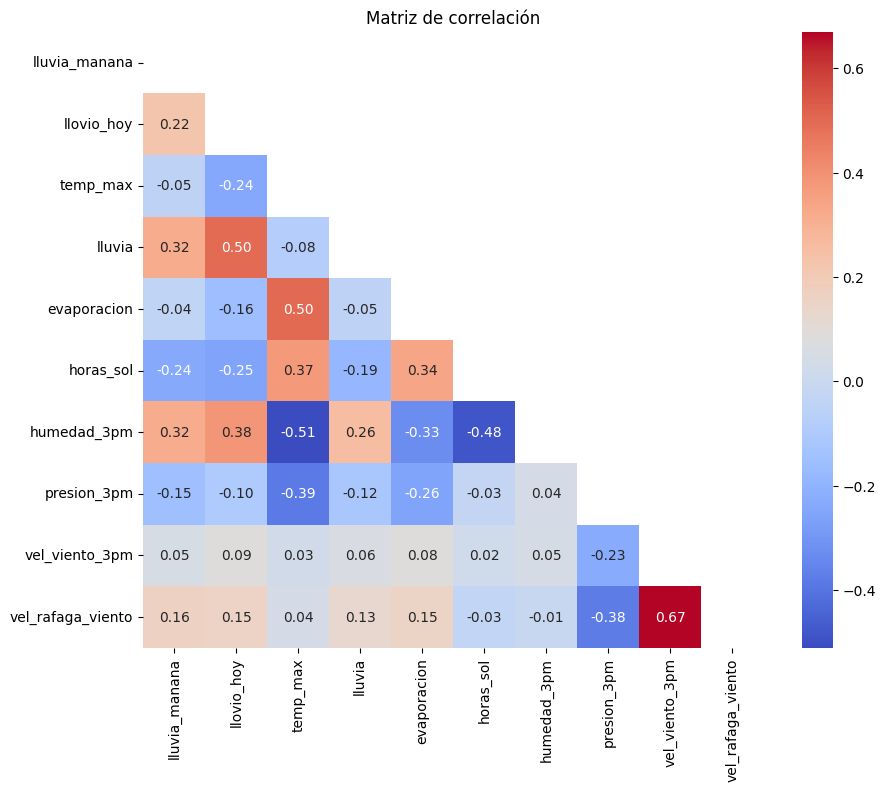

In [43]:
#MATRIZ DE CORRELACIÓN:
vars_corr = ['lluvia_manana','llovio_hoy','temp_max','lluvia','evaporacion','horas_sol','humedad_3pm'
             ,'presion_3pm','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

In [44]:
# One-Hot Encoding:
cols_cat = ['ubicacion','dir_rafaga_viento','dir_viento_9am','dir_viento_3pm']

X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

#Alinear
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Las variables categóricas fueron transformadas a variables numéricas para utilizarlas en el modelo de regresión logística. La variable 'llovio_hoy' fue codificada como binaria, mientras que las variables 'ubicacion','dir_rafaga_viento','dir_viento_9am'y'dir_viento_3pm' fueron transformadas con One-Hot Encoding.

### Estandarización/Escalado:

In [45]:
cols_num = ['temp_max', 'lluvia', 'evaporacion', 'horas_sol', 'humedad_3pm', 'presion_3pm', 'vel_viento_3pm', 'vel_rafaga_viento','nubes_3pm','temp_3pm']

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Regresión Logística:

In [46]:
# Inicializar y entrenar un modelo de regresión logística
modelo_log = LogisticRegression(max_iter=1000,random_state=42)
modelo_log.fit(X_train, y_train)

# Predicción
y_pred = modelo_log.predict(X_test)

# Probabilidad:
y_prob = modelo_log.predict_proba(X_test)[:,1]

In [47]:
# Generar el reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18976
           1       1.00      1.00      1.00      5376

    accuracy                           1.00     24352
   macro avg       1.00      1.00      1.00     24352
weighted avg       1.00      1.00      1.00     24352



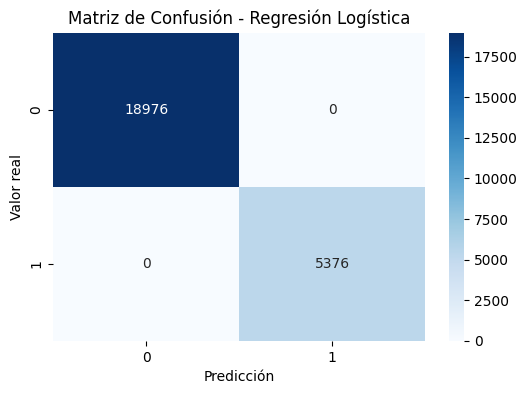

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

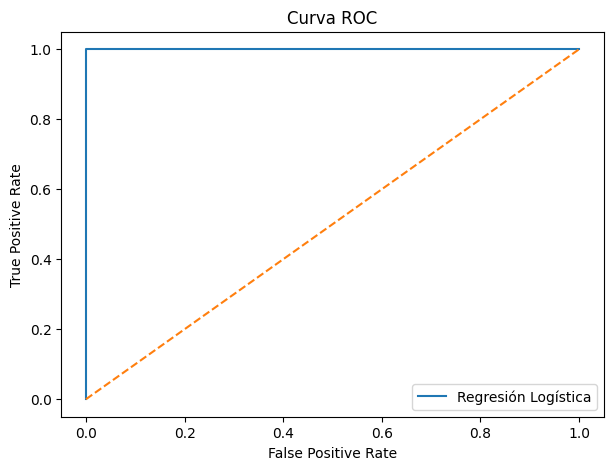

In [135]:


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='Regresión Logística')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()